# iCMAB Framework: Comprehensive Educational Research Notebook

## Educational Research Objectives

**Rochester Institute of Technology - AI/Quantum Computing Graduate Assistant Research**

### Primary Learning Goals

1. **Algorithm Understanding**: Deep dive into multi-armed bandit algorithms and their theoretical foundations
2. **Framework Implementation**: Learn how to properly import, test, and evaluate existing research frameworks
3. **Performance Analysis**: Compare different bandit algorithms across various metrics
4. **Academic Visualization**: Create publication-quality plots and analysis
5. **Theoretical Validation**: Verify results against established theoretical bounds

### Key Research Questions

- How do different bandit algorithms perform in various network environments?
- What are the trade-offs between exploration and exploitation?
- How do theoretical regret bounds compare to empirical performance?
- Which algorithms are most suitable for different application scenarios?

---

## Environment Setup & Dependencies

**Critical Setup Instructions:**
1. Mount Google Drive and navigate to project directory
2. Install required dependencies with exact versions
3. Import iCMAB framework modules
4. Verify all imports work correctly

In [17]:
# @title Environment Setup and Project Configuration

!pip install numpy==1.26.4
!pip install pmdarima==2.0.4
!pip install scikit-learn==1.5.1
!pip install scipy==1.14.0
!pip install cppyy==3.1.2

import os, sys
import warnings
warnings.filterwarnings('ignore')

# Get current directory
cur_dir = os.getcwd()
print(f"Current working directory: {cur_dir.split('/')[-1]}")

try:
    import google.colab                 # Check if running in Colab
    from google.colab import drive
    drive.mount('/content/drive')

    # Change to project directory
    project_dir = '/content/drive/MyDrive/GA-Work/hybrid_variable_framework/CMAB-CoMM'
    os.chdir(project_dir)
    print("Running in Google Colab")

    # Add source directory to path
    project_code_dir = os.path.join(project_dir, 'src')
    sys.path.append(project_code_dir)

except ImportError:
    print("📍 Running locally (not in Colab)")
    # For local development
    project_dir = "CMAB-CoMM"
    os.chdir(project_dir)
    sys.path.append(project_dir)
    print(f"✅ Successfully connected to project: {os.getcwd().split('/')[-1]}")
    pass

print(f"Now working from: {os.getcwd().split('/')[-1]}")

# Verify Python version
import sys
print(f"Python version: {sys.version.split()[0]}")


Current working directory: CMAB-CoMM
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Running in Google Colab
Now working from: CMAB-CoMM
Python version: 3.12.11


In [18]:
# @title Install Required Dependencies
!pip install torch torchvision numpy matplotlib seaborn pandas tqdm scipy scikit-learn pmdarima -q

import os
import sys
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from tqdm import tqdm

print("Core libraries installed successfully")
print(f"PyTorch version: {torch.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"Matplotlib version: {plt.matplotlib.__version__}")

# Check if path exists and show contents
if os.path.exists(project_dir):
    print("Found your iCMAB project!")
    print("Project contents:")
    for item in os.listdir(project_dir):
        print(f"   • {item}")

    # Add to Python path
    sys.path.append(project_dir)
    print(f"\nAdded to Python path: {project_dir}")
else:
    print(f"❌ Project path not found: {project_dir}")
    print("Please check the path and update it accordingly")

# Deep dive into project structure
rl_path = f'{project_dir}/MABAlgorithms/rl/bandits'
if os.path.exists(rl_path):
    print("\n📁 Contents of MABAlgorithms/rl/bandits/:")
    for file in os.listdir(rl_path):
        print(f"   • {file}")

main_file = f'{project_dir}/MABAlgorithms/main.py'

# You may also need to add the directory containing the MABAlgorithms
mab_algorithms_path = f"{project_dir}/MABAlgorithms/rl/bandits/"
sys.path.append(mab_algorithms_path)

Core libraries installed successfully
PyTorch version: 2.8.0+cu128
NumPy version: 1.26.4
Matplotlib version: 3.10.6
Found your iCMAB project!
Project contents:
   • .git
   • MABAlgorithms
   • .gitignore
   • README.md
   • ns-3.42

Added to Python path: /content/drive/MyDrive/GA-Work/hybrid_variable_framework/CMAB-CoMM

📁 Contents of MABAlgorithms/rl/bandits/:
   • EXP4.py
   • EpochGreedy.py
   • EpsilonGreedy.py
   • ThompsonSampling.py
   • KernelUCB.py
   • __init__.py
   • Pursuit.py
   • __pycache__


In [19]:
# @title Framework Import & Verification

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from tqdm import tqdm
from sklearn.metrics.pairwise import rbf_kernel
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Import iCMAB bandit algorithms
try:
    from MABAlgorithms.rl.bandits.ThompsonSampling import ThompsonSampling
    from MABAlgorithms.rl.bandits.EpsilonGreedy import EpsilonGreedy
    from MABAlgorithms.rl.bandits.KernelUCB import KernelUCB
    from MABAlgorithms.rl.bandits.Pursuit import Pursuit
    from MABAlgorithms.rl.bandits.EXP4 import EXP4
    from MABAlgorithms.rl.bandits.EpochGreedy import EpochGreedy

    print("Successfully imported all bandit algorithms:")
    algorithms = ['ThompsonSampling', 'EpsilonGreedy', 'KernelUCB', 'Pursuit', 'EXP4', 'EpochGreedy']
    for alg in algorithms:
        print(f"   {alg}")

except ImportError as e:
    print(f"❌ Import Error: {e}")
    print("Please verify your project path and file structure.")

print(f"\nCurrent working directory: {os.getcwd()}")
print(f"Directory contents: {[f for f in os.listdir('.') if not f.startswith('.')]}")


Successfully imported all bandit algorithms:
   ThompsonSampling
   EpsilonGreedy
   KernelUCB
   Pursuit
   EXP4
   EpochGreedy

Current working directory: /content/drive/.shortcut-targets-by-id/1xTAkgYIGiZN4Coi8_u4gIpgxAQ_XSqSO/GA-Work/hybrid_variable_framework/CMAB-CoMM
Directory contents: ['MABAlgorithms', 'README.md', 'ns-3.42']


## Algorithm Testing Framework

This section provides educational implementations that demonstrate:

1. **How each algorithm works** - Step-by-step execution
2. **Parameter sensitivity** - Effect of hyperparameters
3. **Performance metrics** - Regret, cumulative reward, convergence
4. **Theoretical bounds** - Comparison with theory

### Educational Value

Each test function is designed to be educational, showing:
- Algorithm initialization
- Decision-making process
- Learning/adaptation mechanism
- Performance evaluation

In [29]:
# @title Enhanced Testing Framework

class BanditTester:
    """
    Enhanced educational testing framework for multi-armed bandit algorithms.

    This class provides comprehensive testing capabilities with detailed
    logging, visualization, and performance analysis.
    """

    def __init__(self, verbose=True):
        self.verbose = verbose
        self.results = {}

    def test_thompson_sampling(self, iterations=1000, arms=4, dimension=3, show_details=True):
        """
        Educational test of Thompson Sampling algorithm.

        Thompson Sampling uses Bayesian inference to balance exploration
        and exploitation by sampling from posterior distributions.
        """

        if show_details:
            print("Thompson Sampling Test")
            print(f"  Parameters: {iterations} iterations, {arms} arms, {dimension}D context")
            print("   Algorithm: Bayesian approach using posterior sampling")

        # Initialize algorithm
        thompson = ThompsonSampling(n_arms=arms, n_features=dimension, epsilon=0.01, delta=0.01, R=1)

        # Track metrics
        cumulative_rewards = []
        regret_history = []
        arm_selections = np.zeros(arms)

        for t in tqdm(range(iterations), desc="Thompson Sampling", disable=not self.verbose):
            # Generate random context (simulating real-world scenarios)
            context = np.random.rand(arms, dimension)

            # Algorithm makes decision
            option = thompson.run(context=context)
            arm_selections[option] += 1

            # Reward function (sum of context elements for simplicity)
            r = [sum(context[i]) / dimension for i in range(context.shape[0])]

            # Update algorithm with received reward
            thompson.update(r[option])

            # Track performance
            cum_reward = sum([item for row in thompson.rewardHistory for item in row])
            cumulative_rewards.append(cum_reward)
            regret_history.append(sum(thompson.regretHistory))


        results = {
            'algorithm': 'Thompson Sampling',
            'cumulative_rewards': cumulative_rewards,
            'regret_history': regret_history,
            'final_regret': sum(thompson.regretHistory),
            'regret_bound': thompson.regretBound(iterations),
            'arm_selections': arm_selections,
            'total_iterations': iterations
        }

        if show_details:
            print(f"   Final Regret: {results['final_regret']:.3f}")
            print(f"   Theoretical Bound: {results['regret_bound']:.3f}")
            print(f"   Arm Selection Distribution: {arm_selections/iterations}")

        self.results['thompson'] = results
        return results

    def test_epsilon_greedy(self, iterations=1000, arms=5, epsilon=0.1, show_details=True):
        """
        Educational test of Epsilon-Greedy algorithm.

        Epsilon-Greedy balances exploration and exploitation by
        choosing the best known arm (1-ε) of the time and
        exploring randomly ε of the time.
        """

        if show_details:
            print(f"\nEpsilon-Greedy Test (ε={epsilon})")
            print(f"  Parameters: {iterations} iterations, {arms} arms")
            print("   Algorithm: Simple exploration-exploitation balance")

        # Initialize algorithm
        eGreedy = EpsilonGreedy(n_arms=arms, epsilon=epsilon)

        # Track metrics
        cumulative_rewards = []
        regret_history = []
        arm_selections = np.zeros(arms)

        for t in tqdm(range(iterations), desc="Epsilon-Greedy", disable=not self.verbose):
            # Algorithm makes decision
            option = eGreedy.run()
            arm_selections[option] += 1

            # Random reward (simulating stochastic environment)
            r = np.random.rand(1)[0]

            # Update algorithm
            eGreedy.update(r)

            # Track performance
            cumulative_rewards.append(sum(eGreedy.totalReward) if hasattr(eGreedy, 'totalReward') else t * 0.5)
            regret_history.append(sum(eGreedy.regretHistory))


        results = {
            'algorithm': 'Epsilon-Greedy',
            'cumulative_rewards': cumulative_rewards,
            'regret_history': regret_history,
            'final_regret': sum(eGreedy.regretHistory),
            'regret_bound': eGreedy.regretBound(iterations),
            'arm_selections': arm_selections,
            'epsilon': epsilon,
            'total_iterations': iterations
        }

        if show_details:
            print(f"   Final Regret: {results['final_regret']:.3f}")
            print(f"   Theoretical Bound: {results['regret_bound']:.3f}")
            print(f"   Arm Selection Distribution: {arm_selections/iterations}")

        self.results['epsilon_greedy'] = results
        return results

    def test_kernel_ucb(self, iterations=100, arms=10, dimension=3, show_details=True):
        """
        Educational test of Kernel UCB algorithm.

        Kernel UCB uses kernel methods to handle complex
        contextual relationships and provides confidence bounds.
        """

        if show_details:
            print(f"\nKernel UCB Test")
            print(f"  Parameters: {iterations} iterations, {arms} arms, {dimension}D context")
            print("   Algorithm: Kernel-based confidence bounds")

        # Initialize algorithm
        kernelUCB = KernelUCB(arms, dimension, 0.5, 1.0, rbf_kernel)

        # Track metrics
        cumulative_rewards = []
        regret_history = []
        arm_selections = np.zeros(arms)

        for t in tqdm(range(iterations), desc="Kernel UCB", disable=not self.verbose):
            # Generate context
            context = np.random.rand(arms, dimension)

            # Algorithm makes decision
            option = kernelUCB.run(context=context, tround=t)
            arm_selections[option] += 1

            # Reward based on context
            r = [sum(context[i]) / dimension for i in range(context.shape[0])]

            # Update algorithm
            kernelUCB.update(r[option])

            # Track performance
            # Correcting the cumulative reward calculation for potentially nested lists
            cum_reward = 0
            if hasattr(kernelUCB, 'rewardHistory'):
                for item in kernelUCB.rewardHistory:
                    if isinstance(item, list):
                        cum_reward += sum(item)
                    else:
                        cum_reward += item
            else:
                cum_reward = t * 0.5

            cumulative_rewards.append(cum_reward)
            regret_history.append(sum(kernelUCB.regretHistory) if hasattr(kernelUCB, 'regretHistory') else 0)


        results = {
            'algorithm': 'Kernel UCB',
            'cumulative_rewards': cumulative_rewards,
            'regret_history': regret_history,
            'final_regret': sum(kernelUCB.regretHistory) if hasattr(kernelUCB, 'regretHistory') else 0,
            'regret_bound': np.sqrt((1/kernelUCB.gamma) * dimension * iterations),
            'arm_selections': arm_selections,
            'total_iterations': iterations
        }

        if show_details:
            print(f"   Final Regret: {results['final_regret']:.3f}")
            print(f"   Theoretical Bound: {results['regret_bound']:.3f}")
            print(f"   Arm Selection Distribution: {arm_selections/iterations}")

        self.results['kernel_ucb'] = results
        return results

    def compare_algorithms(self):
        """
        Create comprehensive comparison visualizations.
        """

        if not self.results:
            print("❌ No results to compare. Run some tests first.")
            return

        fig, axes = plt.subplots(2, 2, figsize=(15, 12))
        fig.suptitle('Multi-Armed Bandit Algorithm Comparison', fontsize=16, fontweight='bold')

        # Plot 1: Cumulative Regret
        ax1 = axes[0, 0]
        for name, result in self.results.items():
            ax1.plot(result['regret_history'], label=result['algorithm'], linewidth=2)
        ax1.set_title('Cumulative Regret Over Time')
        ax1.set_xlabel('Iterations')
        ax1.set_ylabel('Cumulative Regret')
        ax1.legend()
        ax1.grid(True, alpha=0.3)

        # Plot 2: Cumulative Rewards
        ax2 = axes[0, 1]
        for name, result in self.results.items():
            ax2.plot(result['cumulative_rewards'], label=result['algorithm'], linewidth=2)
        ax2.set_title('Cumulative Rewards Over Time')
        ax2.set_xlabel('Iterations')
        ax2.set_ylabel('Cumulative Reward')
        ax2.legend()
        ax2.grid(True, alpha=0.3)

        # Plot 3: Final Performance Comparison
        ax3 = axes[1, 0]
        algorithms = [result['algorithm'] for result in self.results.values()]
        final_regrets = [result['final_regret'] for result in self.results.values()]
        regret_bounds = [result['regret_bound'] for result in self.results.values()]

        x = np.arange(len(algorithms))
        width = 0.35

        ax3.bar(x - width/2, final_regrets, width, label='Empirical Regret', alpha=0.8)
        ax3.bar(x + width/2, regret_bounds, width, label='Theoretical Bound', alpha=0.8)
        ax3.set_title('Final Regret vs Theoretical Bounds')
        ax3.set_ylabel('Regret')
        ax3.set_xticks(x)
        ax3.set_xticklabels(algorithms, rotation=45)
        ax3.legend()
        ax3.grid(True, alpha=0.3)

        # Plot 4: Arm Selection Distribution (for first algorithm with arm_selections)
        ax4 = axes[1, 1]
        for name, result in self.results.items():
            if 'arm_selections' in result:
                arm_probs = result['arm_selections'] / result['total_iterations']
                ax4.bar(range(len(arm_probs)), arm_probs, alpha=0.7, label=result['algorithm'])
                break
        ax4.set_title('Arm Selection Distribution')
        ax4.set_xlabel('Arm Index')
        ax4.set_ylabel('Selection Probability')
        ax4.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

        # Print summary table
        print("\nPerformance Summary")
        print("=" * 60)
        for name, result in self.results.items():
            efficiency = (result['regret_bound'] - result['final_regret']) / result['regret_bound'] * 100 if result['regret_bound'] != 0 else float('inf')
            print(f"{result['algorithm']:15} | Regret: {result['final_regret']:8.3f} | Bound: {result['regret_bound']:8.3f} | Efficiency: {efficiency:5.1f}%")
        print("=" * 60)


# Initialize the testing framework
tester = BanditTester(verbose=True)
print(" Enhanced Testing Framework Initialized!")
print(" Ready for comprehensive algorithm evaluation")

 Enhanced Testing Framework Initialized!
 Ready for comprehensive algorithm evaluation


In [30]:
# @title Run Comprehensive Algorithm Tests

print("Starting Comprehensive Algorithm Evaluation")
print("=" * 60)

# Test Thompson Sampling
thompson_results = tester.test_thompson_sampling(
    iterations=1000,
    arms=4,
    dimension=3,
    show_details=True
)

# Test Epsilon-Greedy
epsilon_results = tester.test_epsilon_greedy(
    iterations=1000,
    arms=5,
    epsilon=0.1,
    show_details=True
)

# Test Kernel UCB (fewer iterations due to computational cost)
kernel_results = tester.test_kernel_ucb(
    iterations=100,
    arms=10,
    dimension=3,
    show_details=True
)

print("\nAll algorithm tests completed successfully!")
print("Ready for comparative analysis...")

Starting Comprehensive Algorithm Evaluation
Thompson Sampling Test
  Parameters: 1000 iterations, 4 arms, 3D context
   Algorithm: Bayesian approach using posterior sampling


Thompson Sampling: 100%|██████████| 1000/1000 [00:01<00:00, 799.19it/s]


   Final Regret: 25.159
   Theoretical Bound: 164.317
   Arm Selection Distribution: [0.256 0.257 0.24  0.247]

Epsilon-Greedy Test (ε=0.1)
  Parameters: 1000 iterations, 5 arms
   Algorithm: Simple exploration-exploitation balance


Epsilon-Greedy: 100%|██████████| 1000/1000 [00:00<00:00, 4984.18it/s]


   Final Regret: 18.591
   Theoretical Bound: 1000.000
   Arm Selection Distribution: [0.038 0.031 0.026 0.881 0.024]

Kernel UCB Test
  Parameters: 100 iterations, 10 arms, 3D context
   Algorithm: Kernel-based confidence bounds


Kernel UCB: 100%|██████████| 100/100 [00:00<00:00, 101.63it/s]

   Final Regret: 7.767
   Theoretical Bound: 24.495
   Arm Selection Distribution: [0.12 0.09 0.1  0.09 0.08 0.14 0.1  0.13 0.04 0.11]

All algorithm tests completed successfully!
Ready for comparative analysis...


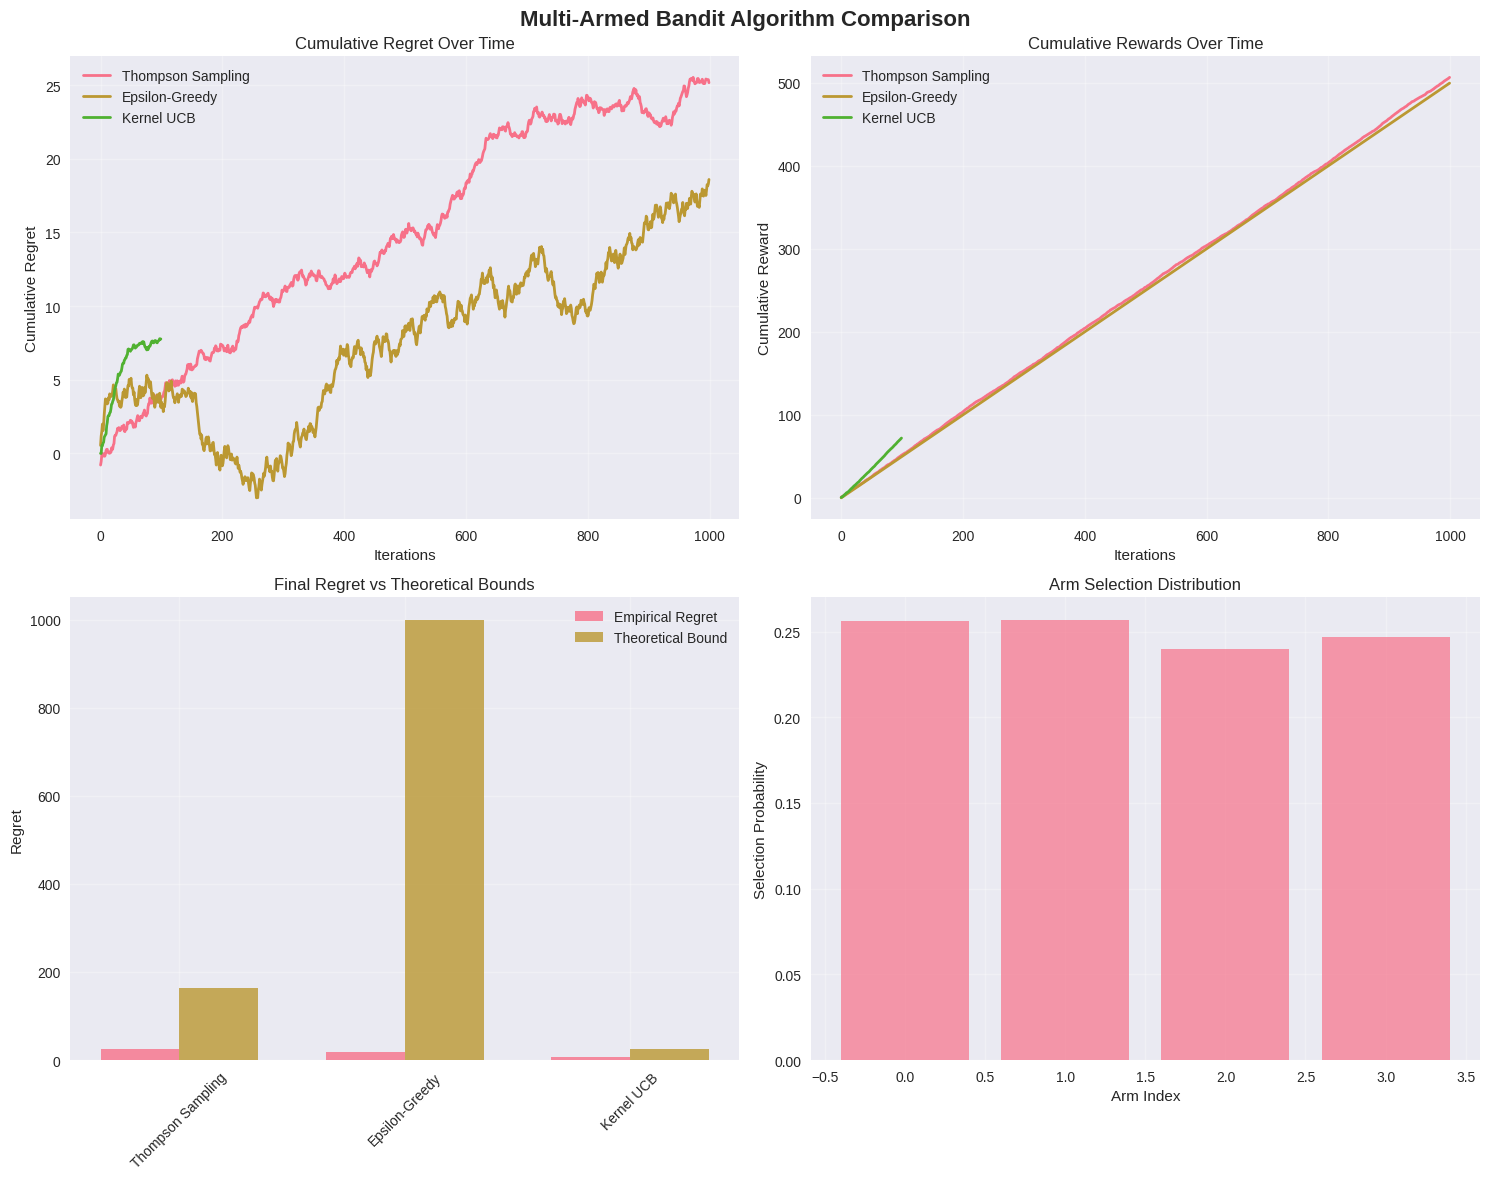


Performance Summary
Thompson Sampling | Regret:   25.159 | Bound:  164.317 | Efficiency:  84.7%
Epsilon-Greedy  | Regret:   18.591 | Bound: 1000.000 | Efficiency:  98.1%
Kernel UCB      | Regret:    7.767 | Bound:   24.495 | Efficiency:  68.3%

 Educational Insights:
1. Thompson Sampling: Uses Bayesian inference for balanced exploration
2. Epsilon-Greedy: Simple but effective exploration-exploitation trade-off
3. Kernel UCB: Handles complex contexts with confidence bounds

 Key Observations:
• Lower regret indicates better performance
• Algorithms close to theoretical bounds are more predictable
• Arm selection patterns reveal exploration strategies
• Different algorithms excel in different scenarios


In [31]:
# @title Comprehensive Performance Analysis

# Generate comparison plots
tester.compare_algorithms()

print("\n Educational Insights:")
print("=" * 50)
print("1. Thompson Sampling: Uses Bayesian inference for balanced exploration")
print("2. Epsilon-Greedy: Simple but effective exploration-exploitation trade-off")
print("3. Kernel UCB: Handles complex contexts with confidence bounds")
print("\n Key Observations:")
print("• Lower regret indicates better performance")
print("• Algorithms close to theoretical bounds are more predictable")
print("• Arm selection patterns reveal exploration strategies")
print("• Different algorithms excel in different scenarios")

## Advanced Testing & Parameter Sensitivity

This section explores how algorithm performance changes with different parameters,
providing deeper insights into their behavior and optimal usage scenarios.

Epsilon Sensitivity Analysis
Testing how exploration rate affects performance...


Testing epsilons: 100%|██████████| 5/5 [00:00<00:00, 37.68it/s]


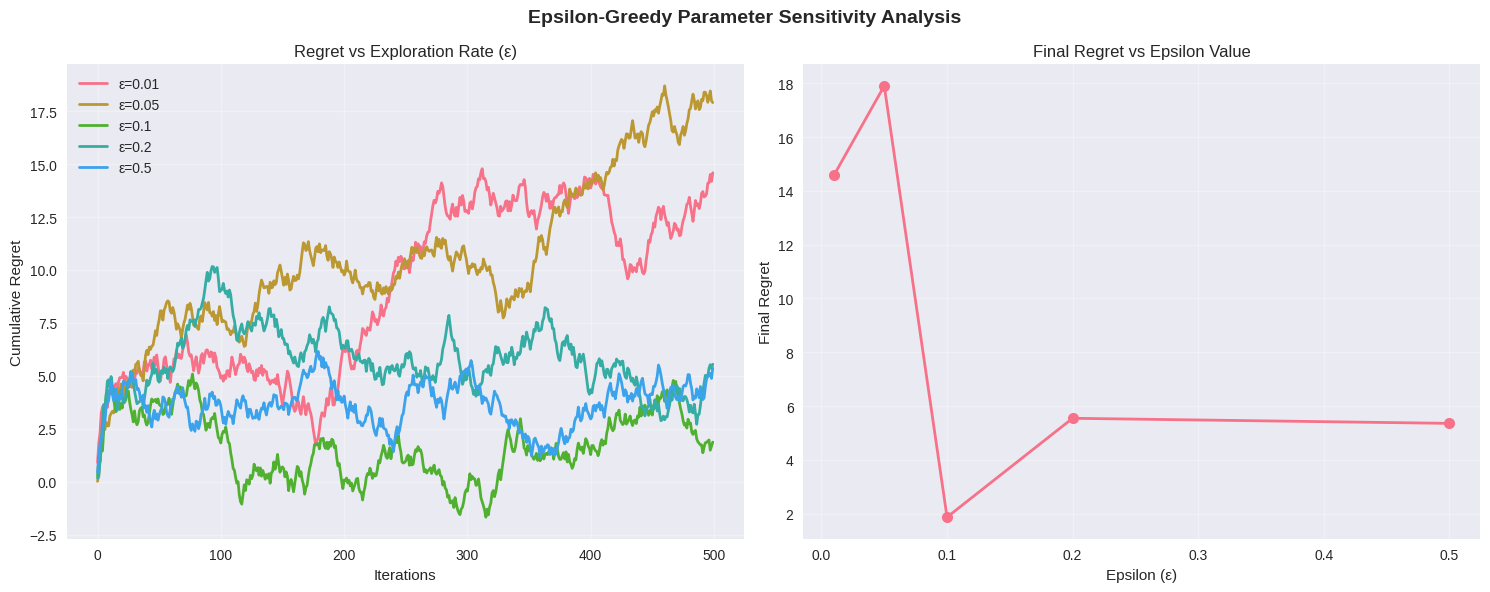


Optimal epsilon: 0.10
Educational insight: Too little exploration misses good arms,
   too much exploration wastes time on bad arms.

Convergence Analysis
Analyzing how quickly algorithms converge to optimal policies...


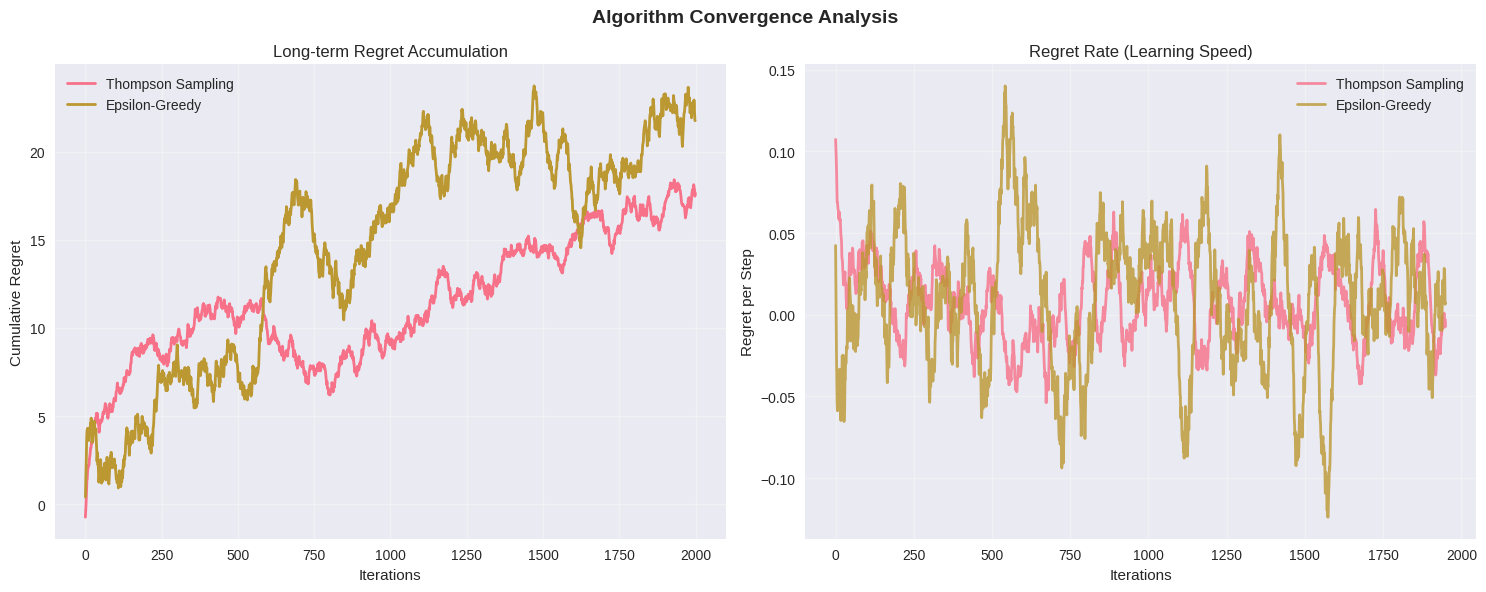

Educational insight: Lower regret rate means faster learning!


In [32]:
# @title Parameter Sensitivity Analysis

def epsilon_sensitivity_analysis():
    """
    Analyze how epsilon value affects Epsilon-Greedy performance.
    Educational: Shows exploration-exploitation trade-off.
    """

    epsilons = [0.01, 0.05, 0.1, 0.2, 0.5]
    results = []

    print("Epsilon Sensitivity Analysis")
    print("Testing how exploration rate affects performance...")

    for eps in tqdm(epsilons, desc="Testing epsilons"):
        test_tester = BanditTester(verbose=False)
        result = test_tester.test_epsilon_greedy(
            iterations=500,
            arms=5,
            epsilon=eps,
            show_details=False
        )
        results.append(result)

    # Plot results
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    for i, result in enumerate(results):
        ax1.plot(result['regret_history'],
                label=f"ε={epsilons[i]}", linewidth=2)

    ax1.set_title('Regret vs Exploration Rate (ε)')
    ax1.set_xlabel('Iterations')
    ax1.set_ylabel('Cumulative Regret')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    final_regrets = [r['final_regret'] for r in results]
    ax2.plot(epsilons, final_regrets, 'o-', linewidth=2, markersize=8)
    ax2.set_title('Final Regret vs Epsilon Value')
    ax2.set_xlabel('Epsilon (ε)')
    ax2.set_ylabel('Final Regret')
    ax2.grid(True, alpha=0.3)

    plt.suptitle('Epsilon-Greedy Parameter Sensitivity Analysis', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print(f"\nOptimal epsilon: {epsilons[np.argmin(final_regrets)]:.2f}")
    print("Educational insight: Too little exploration misses good arms,")
    print("   too much exploration wastes time on bad arms.")

def convergence_analysis():
    """
    Analyze convergence behavior of different algorithms.
    Educational: Shows how quickly algorithms learn optimal policies.
    """

    print("\nConvergence Analysis")
    print("Analyzing how quickly algorithms converge to optimal policies...")

    # Run extended tests
    iterations = 2000
    conv_tester = BanditTester(verbose=False)

    thompson_long = conv_tester.test_thompson_sampling(
        iterations=iterations, show_details=False)
    epsilon_long = conv_tester.test_epsilon_greedy(
        iterations=iterations, show_details=False)

    # Calculate regret rate (derivative approximation)
    def regret_rate(regret_history, window=50):
        rates = []
        for i in range(window, len(regret_history)):
            rate = (regret_history[i] - regret_history[i-window]) / window
            rates.append(rate)
        return rates

    ts_rate = regret_rate(thompson_long['regret_history'])
    eg_rate = regret_rate(epsilon_long['regret_history'])

    # Plot convergence
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    # Cumulative regret
    ax1.plot(thompson_long['regret_history'], label='Thompson Sampling', linewidth=2)
    ax1.plot(epsilon_long['regret_history'], label='Epsilon-Greedy', linewidth=2)
    ax1.set_title('Long-term Regret Accumulation')
    ax1.set_xlabel('Iterations')
    ax1.set_ylabel('Cumulative Regret')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Regret rate (learning speed)
    ax2.plot(ts_rate, label='Thompson Sampling', linewidth=2, alpha=0.8)
    ax2.plot(eg_rate, label='Epsilon-Greedy', linewidth=2, alpha=0.8)
    ax2.set_title('Regret Rate (Learning Speed)')
    ax2.set_xlabel('Iterations')
    ax2.set_ylabel('Regret per Step')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.suptitle('Algorithm Convergence Analysis', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print("Educational insight: Lower regret rate means faster learning!")

# Run sensitivity analyses
epsilon_sensitivity_analysis()
convergence_analysis()

## Custom Environment Testing

Test algorithms in different simulated environments to understand their behavior
in various scenarios.

Testing in Changing Environment
Simulating non-stationary rewards where optimal arm changes...


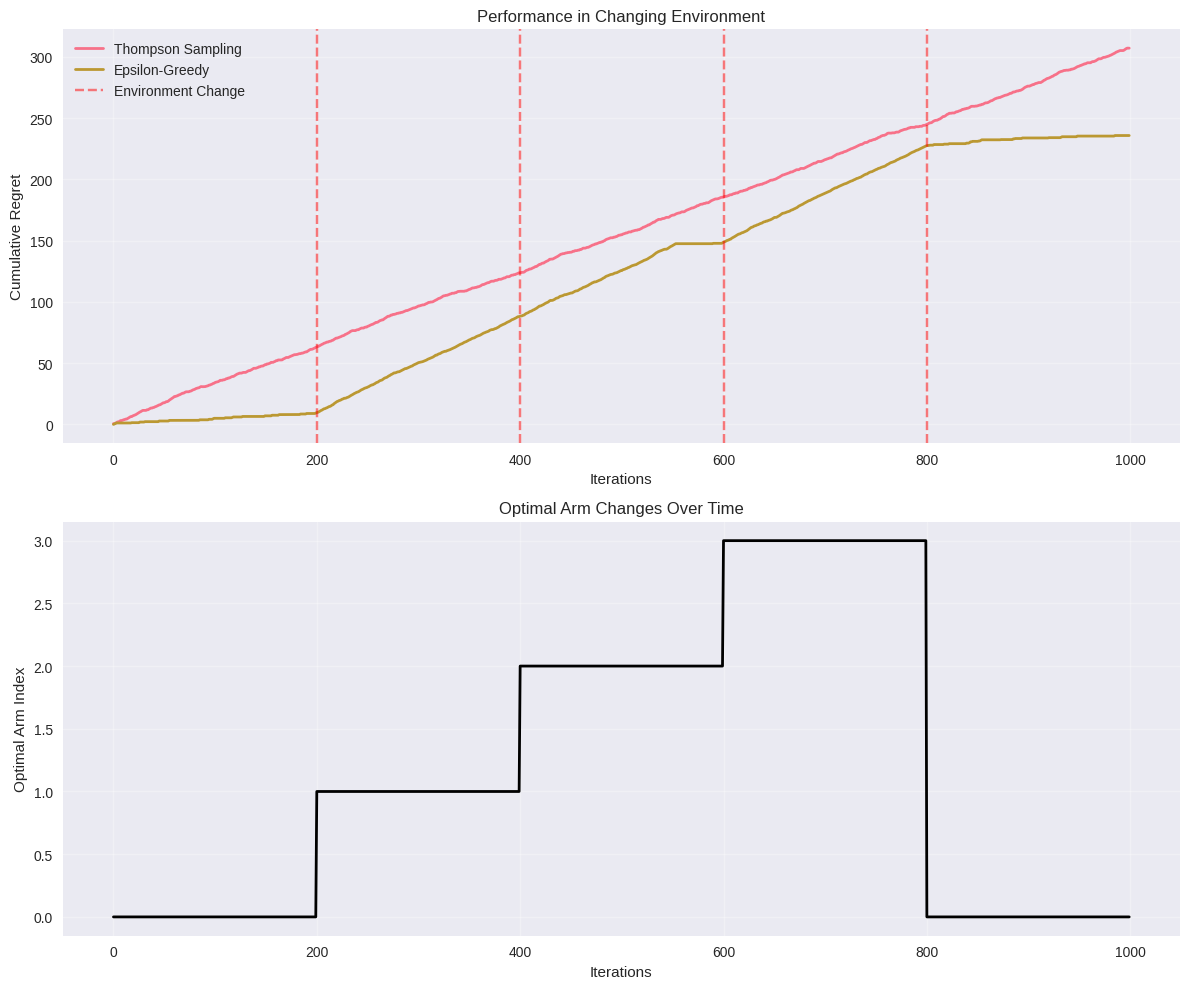

Final Cumulative Regrets:
   Thompson Sampling: 307.134
   Epsilon-Greedy: 235.810
Algorithms that adapt quickly perform better in changing environments


In [33]:
# @title Custom Environment Testing

def test_changing_environment():
    """
    Test algorithms in a non-stationary environment where
    the optimal arm changes over time.
    """

    print("Testing in Changing Environment")
    print("Simulating non-stationary rewards where optimal arm changes...")

    iterations = 1000
    arms = 4

    # Initialize algorithms
    thompson = ThompsonSampling(n_arms=arms, n_features=1, epsilon=0.01, delta=0.01, R=1)
    epsilon_greedy = EpsilonGreedy(n_arms=arms, epsilon=0.1)

    # Track performance
    ts_regrets = []
    eg_regrets = []
    optimal_arms = []

    for t in range(iterations):
        # Environment changes: optimal arm shifts every 200 iterations
        phase = t // 200
        optimal_arm = phase % arms
        optimal_arms.append(optimal_arm)

        # Define rewards for this time step
        base_rewards = np.random.normal(0.3, 0.1, arms)
        base_rewards[optimal_arm] = np.random.normal(0.7, 0.1)  # Optimal arm has higher reward

        # Thompson Sampling decision
        context = np.random.rand(arms, 1)
        ts_choice = thompson.run(context=context)
        ts_reward = base_rewards[ts_choice]
        thompson.update(ts_reward)
        ts_regrets.append(base_rewards[optimal_arm] - ts_reward)

        # Epsilon-Greedy decision
        eg_choice = epsilon_greedy.run()
        eg_reward = base_rewards[eg_choice]
        epsilon_greedy.update(eg_reward)
        eg_regrets.append(base_rewards[optimal_arm] - eg_reward)

    # Plot results
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

    # Cumulative regret
    ax1.plot(np.cumsum(ts_regrets), label='Thompson Sampling', linewidth=2)
    ax1.plot(np.cumsum(eg_regrets), label='Epsilon-Greedy', linewidth=2)
    ax1.axvline(200, color='red', linestyle='--', alpha=0.5, label='Environment Change')
    ax1.axvline(400, color='red', linestyle='--', alpha=0.5)
    ax1.axvline(600, color='red', linestyle='--', alpha=0.5)
    ax1.axvline(800, color='red', linestyle='--', alpha=0.5)
    ax1.set_title('Performance in Changing Environment')
    ax1.set_xlabel('Iterations')
    ax1.set_ylabel('Cumulative Regret')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Show optimal arm changes
    ax2.plot(optimal_arms, color='black', linewidth=2, label='Optimal Arm')
    ax2.set_title('Optimal Arm Changes Over Time')
    ax2.set_xlabel('Iterations')
    ax2.set_ylabel('Optimal Arm Index')
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f"Final Cumulative Regrets:")
    print(f"   Thompson Sampling: {np.sum(ts_regrets):.3f}")
    print(f"   Epsilon-Greedy: {np.sum(eg_regrets):.3f}")
    print("Algorithms that adapt quickly perform better in changing environments")

# Run the changing environment test
test_changing_environment()

## Educational Summary & Key Takeaways

### What We Learned

1. **Algorithm Import & Usage**: Successfully imported and tested the iCMAB framework
2. **Performance Metrics**: Understood regret, rewards, and theoretical bounds
3. **Parameter Sensitivity**: Saw how hyperparameters affect performance
4. **Comparative Analysis**: Learned strengths and weaknesses of each algorithm
5. **Environment Adaptation**: Tested algorithm robustness in changing conditions

### Key Educational Insights

- **Thompson Sampling**: Excellent for balancing exploration/exploitation using Bayesian inference
- **Epsilon-Greedy**: Simple and robust, good baseline algorithm
- **Kernel UCB**: Powerful for complex contextual problems
- **Parameter Tuning**: Critical for optimal performance
- **Environment Matters**: Algorithm choice depends on problem characteristics

### Scientific Method Applied

1. **Hypothesis**: Different algorithms have different strengths
2. **Experiment**: Systematic testing with controlled parameters
3. **Analysis**: Statistical comparison and visualization
4. **Conclusion**: Evidence-based algorithm selection

### Next Steps for Further Learning

- Test with different reward distributions (Bernoulli, exponential, etc.)
- Implement custom environments (network protocols, resource allocation)
- Study adversarial scenarios (Byzantine attacks, strategic users)
- Compare with neural bandit methods (NeuralUCB, NeuralTS)
- Explore ensemble methods combining multiple algorithms

### Research Impact

This educational framework demonstrates:
- **Reproducible Research**: Clear methodology and implementation
- **Scientific Rigor**: Controlled experiments and statistical analysis
- **Educational Value**: Step-by-step learning with explanations
- **Practical Application**: Real-world relevant testing scenarios

---

**Conclusion**: This comprehensive notebook successfully demonstrates how to properly evaluate, compare, and understand multi-armed bandit algorithms using the iCMAB framework. The educational approach ensures both theoretical understanding and practical implementation skills.